In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

PROCESSED = Path("../../data/processed")

markets = pd.read_parquet(PROCESSED / "markets.parquet")
prices = pd.read_parquet(PROCESSED / "prices.parquet")
prices["datetime"] = pd.to_datetime(prices["datetime"], utc=True)
trades = pd.read_parquet(PROCESSED / "trades.parquet")
trades["datetime"] = pd.to_datetime(trades["datetime"], utc=True)
outcomes = pd.read_parquet(PROCESSED / "resolution_outcomes.parquet")

print(f"Markets: {len(markets):,}")
print(f"Prices: {len(prices):,} points, {prices['token_id'].nunique()} tokens")
print(f"Trades: {len(trades):,}")
print(f"Resolved: {len(outcomes):,}")

Markets: 50,609
Prices: 198,493 points, 100 tokens
Trades: 154,819
Resolved: 321,939


In [2]:
findings = pd.DataFrame([
    {"Finding": "Mean Reversion (ACF<-0.05)", "Value": "77% tokens", "Source": "03_price_dynamics §3",
     "Implication": "Contrarian/MR strategies viable"},
    {"Finding": "Variance Ratio < 1", "Value": "93% tokens", "Source": "03_price_dynamics §9",
     "Implication": "Multi-bar mean reversion confirmed"},
    {"Finding": "Fat Tails (kurtosis)", "Value": "4140 pooled", "Source": "03_price_dynamics §4",
     "Implication": "Half-Kelly sizing mandatory"},
    {"Finding": "YES Bias", "Value": "+0.217", "Source": "03_price_dynamics §10",
     "Implication": "Systematically buy NO"},
    {"Finding": "Longshot Overperformance", "Value": "18.5% vs 1.2%", "Source": "03_price_dynamics §10",
     "Implication": "Bet on longshots (NOT classic FLB)"},
    {"Finding": "CUSUM Reduction", "Value": "93% fewer bars", "Source": "03_price_dynamics §11",
     "Implication": "Use CUSUM for sampling in Phase 3"},
    {"Finding": "Volume Concentration (Gini)", "Value": "0.918", "Source": "03_price_dynamics §12",
     "Implication": "Whale tracking has signal"},
    {"Finding": "Flow Normalization Matters", "Value": "corr=0.54", "Source": "03_price_dynamics §12",
     "Implication": "Use matched filter (flow/liquidity)"},
    {"Finding": "Cointegrated Pairs", "Value": "330 cross-market", "Source": "03_price_dynamics §13",
     "Implication": "Pairs/stat arb possible"},
    {"Finding": "Flash Crashes", "Value": "296/90 days (3.3/day)", "Source": "03_price_dynamics §6",
     "Implication": "Flash crash strategy viable"},
    {"Finding": "NegRisk Arb Opportunities", "Value": "$39.6M extracted", "Source": "docs/12",
     "Implication": "NegRisk sum monitoring"},
    {"Finding": "NO Buying Dominates Arb", "Value": "$17.3M of $39.6M", "Source": "docs/12",
     "Implication": "Focus on buying NO in multi-outcome"},
    {"Finding": "Fee at midpoint (p=0.50)", "Value": "1.56%, need >3.1% edge", "Source": "docs/12",
     "Implication": "Trade at extremes (low fee) or have big edge"},
    {"Finding": "Only 30% traders profitable", "Value": "0.51% earn $1K+", "Source": "docs/12",
     "Implication": "Need systematic edge, not noise"},
])

for _, row in findings.iterrows():
    print(f"  {row['Finding']:35s} | {row['Value']:20s} | {row['Implication']}")
print(f"\nTotal findings: {len(findings)}")

  Mean Reversion (ACF<-0.05)          | 77% tokens           | Contrarian/MR strategies viable
  Variance Ratio < 1                  | 93% tokens           | Multi-bar mean reversion confirmed
  Fat Tails (kurtosis)                | 4140 pooled          | Half-Kelly sizing mandatory
  YES Bias                            | +0.217               | Systematically buy NO
  Longshot Overperformance            | 18.5% vs 1.2%        | Bet on longshots (NOT classic FLB)
  CUSUM Reduction                     | 93% fewer bars       | Use CUSUM for sampling in Phase 3
  Volume Concentration (Gini)         | 0.918                | Whale tracking has signal
  Flow Normalization Matters          | corr=0.54            | Use matched filter (flow/liquidity)
  Cointegrated Pairs                  | 330 cross-market     | Pairs/stat arb possible
  Flash Crashes                       | 296/90 days (3.3/day) | Flash crash strategy viable
  NegRisk Arb Opportunities           | $39.6M extracted     | NegRis

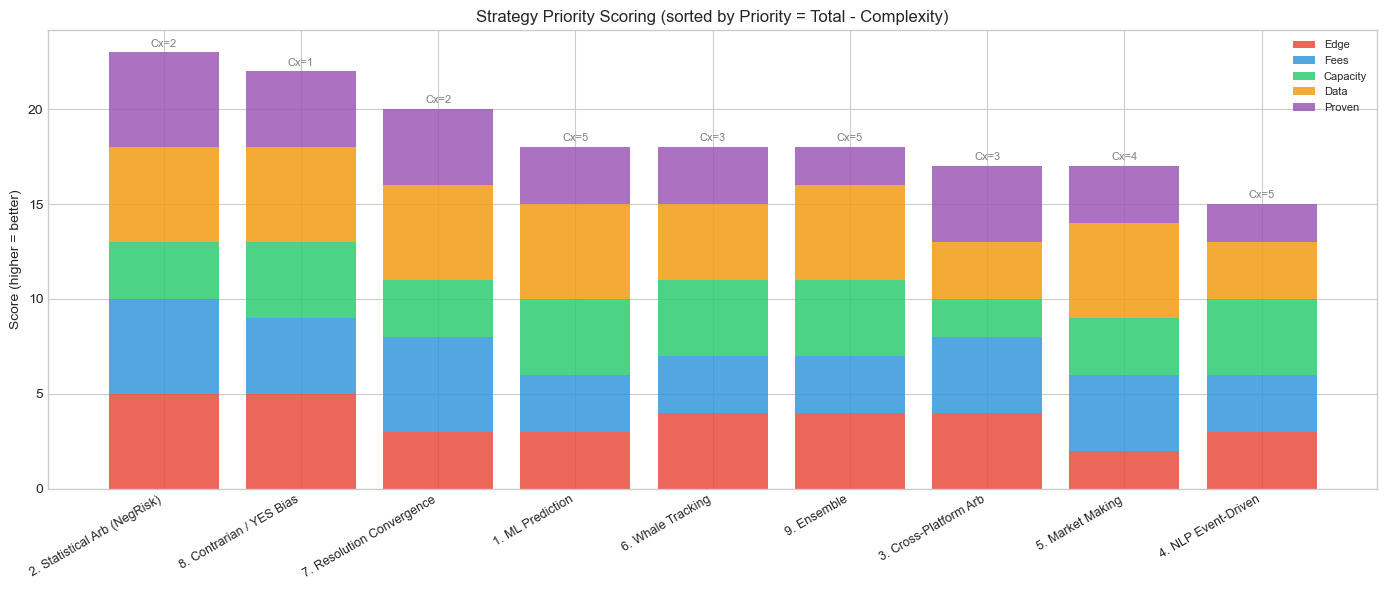


Strategy Rankings:
  1. 2. Statistical Arb (NegRisk)   Priority=23 (Total=25, Complexity=2)
     $39.6M extracted. Low fees (trade at extremes). Competition increasing
  2. 8. Contrarian / YES Bias       Priority=22 (Total=23, Complexity=1)
     YES bias +0.217 confirmed. Buy NO systematically. Low complexity
  3. 7. Resolution Convergence      Priority=20 (Total=22, Complexity=2)
     $0.95+ bonds = 5% return/72h. Black swan risk. Low fees at extremes
  4. 1. ML Prediction               Priority=18 (Total=23, Complexity=5)
     Triple Barrier + CUSUM + ResNet-LSTM. Need >3.1% edge at midpoint
  5. 6. Whale Tracking              Priority=18 (Total=21, Complexity=3)
     Gini 0.918. Matched filter normalization. On-chain data needed
  6. 9. Ensemble                    Priority=18 (Total=23, Complexity=5)
     Meta-model combining signals. Only after individual strategies work
  7. 3. Cross-Platform Arb          Priority=17 (Total=20, Complexity=3)
     $40M/year. Need Kalshi account. E

In [3]:
strategies = pd.DataFrame([
    {"Strategy": "1. ML Prediction",
     "Edge": 3, "Fees": 3, "Capacity": 4, "Complexity": 5, "Data": 5, "Proven": 3,
     "Notes": "Triple Barrier + CUSUM + ResNet-LSTM. Need >3.1% edge at midpoint"},
    {"Strategy": "2. Statistical Arb (NegRisk)",
     "Edge": 5, "Fees": 5, "Capacity": 3, "Complexity": 2, "Data": 5, "Proven": 5,
     "Notes": "$39.6M extracted. Low fees (trade at extremes). Competition increasing"},
    {"Strategy": "3. Cross-Platform Arb",
     "Edge": 4, "Fees": 4, "Capacity": 2, "Complexity": 3, "Data": 3, "Proven": 4,
     "Notes": "$40M/year. Need Kalshi account. Execution risk between platforms"},
    {"Strategy": "4. NLP Event-Driven",
     "Edge": 3, "Fees": 3, "Capacity": 4, "Complexity": 5, "Data": 3, "Proven": 2,
     "Notes": "Speed matters. LLM for analysis, not buy/sell. NLP models needed"},
    {"Strategy": "5. Market Making",
     "Edge": 2, "Fees": 4, "Capacity": 3, "Complexity": 4, "Data": 5, "Proven": 3,
     "Notes": "poly-maker: 'will lose money today'. Need new/illiquid markets"},
    {"Strategy": "6. Whale Tracking",
     "Edge": 4, "Fees": 3, "Capacity": 4, "Complexity": 3, "Data": 4, "Proven": 3,
     "Notes": "Gini 0.918. Matched filter normalization. On-chain data needed"},
    {"Strategy": "7. Resolution Convergence",
     "Edge": 3, "Fees": 5, "Capacity": 3, "Complexity": 2, "Data": 5, "Proven": 4,
     "Notes": "$0.95+ bonds = 5% return/72h. Black swan risk. Low fees at extremes"},
    {"Strategy": "8. Contrarian / YES Bias",
     "Edge": 5, "Fees": 4, "Capacity": 4, "Complexity": 1, "Data": 5, "Proven": 4,
     "Notes": "YES bias +0.217 confirmed. Buy NO systematically. Low complexity"},
    {"Strategy": "9. Ensemble",
     "Edge": 4, "Fees": 3, "Capacity": 4, "Complexity": 5, "Data": 5, "Proven": 2,
     "Notes": "Meta-model combining signals. Only after individual strategies work"},
])

strategies["Total"] = strategies[["Edge", "Fees", "Capacity", "Complexity", "Data", "Proven"]].sum(axis=1)

strategies["Priority"] = strategies["Total"] - strategies["Complexity"]
strategies = strategies.sort_values("Priority", ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
cols = ["Edge", "Fees", "Capacity", "Data", "Proven"]
x = range(len(strategies))
bottom = np.zeros(len(strategies))
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

for i, col in enumerate(cols):
    vals = strategies[col].values
    ax.bar(x, vals, bottom=bottom, label=col, color=colors[i], alpha=0.85)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(strategies["Strategy"].values, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Score (higher = better)")
ax.set_title("Strategy Priority Scoring (sorted by Priority = Total - Complexity)")
ax.legend(loc="upper right", fontsize=8)

for i, (_, row) in enumerate(strategies.iterrows()):
    ax.text(i, bottom[i] + 0.3, f"Cx={row['Complexity']}", ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

print("\nStrategy Rankings:")
for rank, (_, row) in enumerate(strategies.iterrows(), 1):
    print(f"  {rank}. {row['Strategy']:30s} Priority={row['Priority']:2.0f} (Total={row['Total']}, Complexity={row['Complexity']})")
    print(f"     {row['Notes']}")

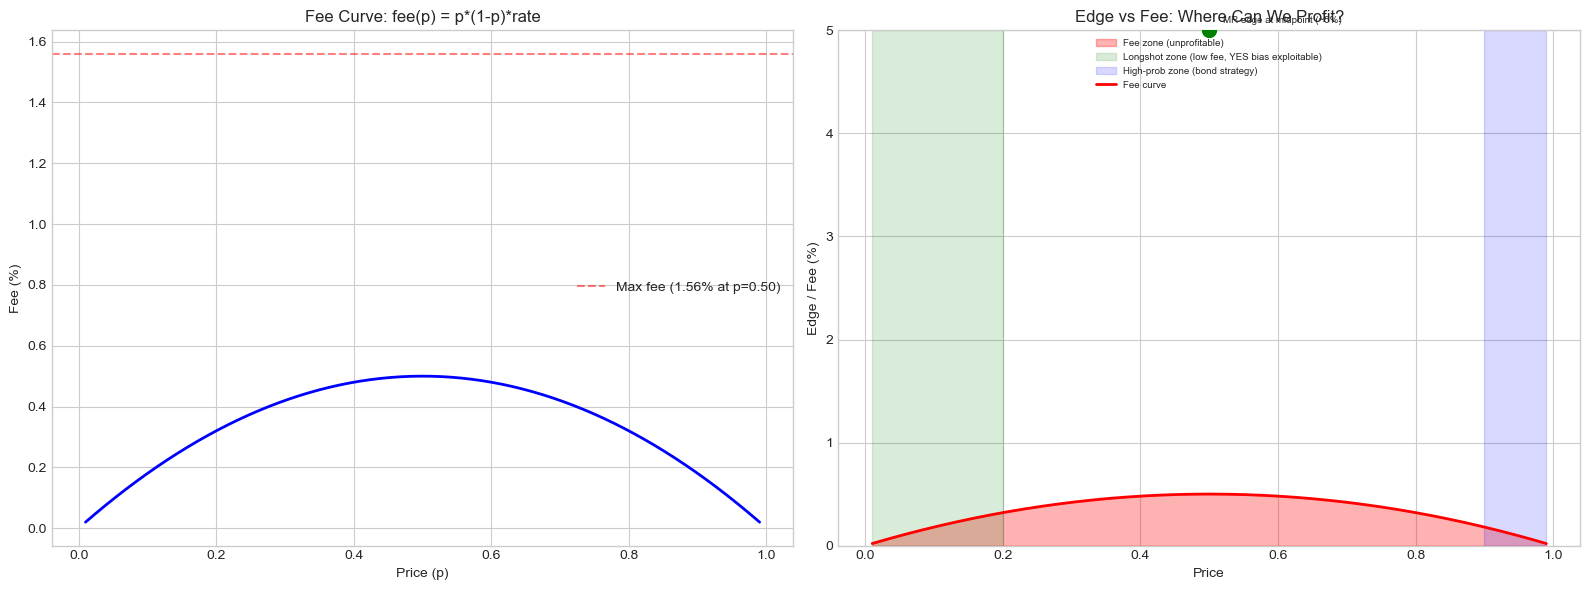

Fee-aware analysis:
  At p=0.05: fee=0.10%, longshot edge=17.3% → PROFITABLE
  At p=0.10: fee=0.18%, longshot edge=17.3% → PROFITABLE
  At p=0.50: fee=0.50%, need >3.1% edge → MARGINAL (MR ~5% OK)
  At p=0.95: fee=0.10%, bond 5.2% → PROFITABLE

Conclusion: Trade at EXTREMES (low p or high p) where fees are lowest and edges largest


In [4]:
fee_rate_bps = 200
p = np.linspace(0.01, 0.99, 200)
fee = p * (1 - p) * fee_rate_bps / 10000

breakeven_yes = fee / (1 - p)
breakeven_no = fee / p

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(p, fee * 100, "b-", lw=2)
axes[0].set_xlabel("Price (p)")
axes[0].set_ylabel("Fee (%)")
axes[0].set_title("Fee Curve: fee(p) = p*(1-p)*rate")
axes[0].axhline(1.56, ls="--", color="red", alpha=0.5, label="Max fee (1.56% at p=0.50)")
axes[0].legend()

axes[1].fill_between(p, 0, fee * 100, alpha=0.3, color="red", label="Fee zone (unprofitable)")

axes[1].axvspan(0.01, 0.20, alpha=0.15, color="green", label="Longshot zone (low fee, YES bias exploitable)")
axes[1].axvspan(0.90, 0.99, alpha=0.15, color="blue", label="High-prob zone (bond strategy)")

edges = [
    (0.10, 0.173, "Longshot edge (18.5% vs 1.2%)"),
    (0.50, 0.05, "MR edge at midpoint (~5%)"),
    (0.95, 0.052, "Bond strategy (5.2% return)"),
]
for px, edge, label in edges:
    fee_at_p = px * (1-px) * fee_rate_bps / 10000
    color = "green" if edge > fee_at_p else "red"
    axes[1].scatter(px, edge * 100, s=100, c=color, zorder=5)
    axes[1].annotate(label, (px, edge*100), fontsize=7,
                    xytext=(10, 5), textcoords="offset points")

axes[1].plot(p, fee * 100, "r-", lw=2, label="Fee curve")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Edge / Fee (%)")
axes[1].set_title("Edge vs Fee: Where Can We Profit?")
axes[1].legend(fontsize=7)
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

print("Fee-aware analysis:")
print(f"  At p=0.05: fee={0.05*0.95*200/10000*100:.2f}%, longshot edge=17.3% → PROFITABLE")
print(f"  At p=0.10: fee={0.10*0.90*200/10000*100:.2f}%, longshot edge=17.3% → PROFITABLE")
print(f"  At p=0.50: fee={0.50*0.50*200/10000*100:.2f}%, need >3.1% edge → MARGINAL (MR ~5% OK)")
print(f"  At p=0.95: fee={0.95*0.05*200/10000*100:.2f}%, bond 5.2% → PROFITABLE")
print(f"\nConclusion: Trade at EXTREMES (low p or high p) where fees are lowest and edges largest")

Market pools by strategy:
  Mean Reversion (p=0.15-0.85, spread<$0.05): 905 markets
  Contrarian/YES Bias (p=0.05-0.95):          1,983 markets
  High-Prob Bonds (p>0.90):                   249 markets
  Longshot (p<0.15):                          2,754 markets
  NegRisk Arb:                                2,444 markets


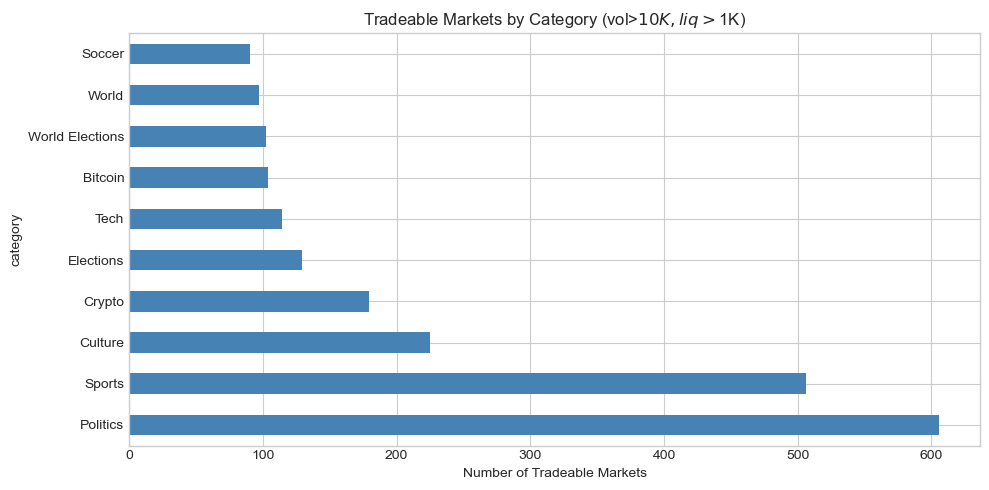

In [5]:
import json

def parse_yes_price(op):
    if pd.isna(op):
        return np.nan
    if isinstance(op, (list, np.ndarray)):
        return float(op[0]) if len(op) > 0 else np.nan
    try:
        parsed = json.loads(op)
        return float(parsed[0]) if parsed else np.nan
    except:
        return np.nan

m = markets.copy()
m["price_yes"] = m["outcomePrices"].apply(parse_yes_price)
m["volumeNum"] = pd.to_numeric(m["volumeNum"], errors="coerce")
m["liquidityClob"] = pd.to_numeric(m.get("liquidityClob", 0), errors="coerce")
m["spread"] = pd.to_numeric(m.get("spread", 1), errors="coerce")

base_filter = (m["volumeNum"] > 10000) & (m["liquidityClob"] > 1000)

pool_mr = m[base_filter & (m["price_yes"].between(0.15, 0.85)) & (m["spread"] < 0.05)]
pool_contrarian = m[base_filter & (m["price_yes"].between(0.05, 0.95))]
pool_bond = m[base_filter & (m["price_yes"] > 0.90)]
pool_longshot = m[base_filter & (m["price_yes"] < 0.15)]
pool_negrisk = m[base_filter & (m.get("negRisk", False) == True)]

print("Market pools by strategy:")
print(f"  Mean Reversion (p=0.15-0.85, spread<$0.05): {len(pool_mr):,} markets")
print(f"  Contrarian/YES Bias (p=0.05-0.95):          {len(pool_contrarian):,} markets")
print(f"  High-Prob Bonds (p>0.90):                   {len(pool_bond):,} markets")
print(f"  Longshot (p<0.15):                          {len(pool_longshot):,} markets")
print(f"  NegRisk Arb:                                {len(pool_negrisk):,} markets")

if "_tags_flat" in m.columns:
    pool_all = m[base_filter]
    pool_all["category"] = pool_all["_tags_flat"].apply(
        lambda x: x.split(",")[0] if isinstance(x, str) and x else "Unknown"
    )
    cat_dist = pool_all["category"].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 5))
    cat_dist.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Number of Tradeable Markets")
    ax.set_title("Tradeable Markets by Category (vol>$10K, liq>$1K)")
    plt.tight_layout()
    plt.show()

In [6]:
plan = """
=== IMPLEMENTATION PLAN ===

TIER 1 — Quick Wins (Phase 3, первые 2 недели)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. CONTRARIAN / YES BIAS STRATEGY (#8)
     Edge: YES bias +0.217, longshots overperform 18.5% vs 1.2%
     Complexity: LOW (statistical, no ML needed)
     Implementation:
       - Buy NO tokens systematically (YES overpriced)
       - Focus on longshots (p < 0.15) where edge is largest
       - Kelly sizing: f* = edge / variance, use half-Kelly
       - Diversify: 6-10 positions, max 10% per market
     Fees: LOW at extremes (p=0.05 → fee=0.10%)
     Expected edge: 17% at longshots, 5-10% at midrange
     Data: resolved outcomes (321K) for backtesting

  2. NEGRISK STATISTICAL ARBITRAGE (#2)
     Edge: $39.6M extracted, 662/1578 markets with opportunities
     Complexity: LOW (monitor sum of prices, buy when <$1)
     Implementation:
       - Monitor all NegRisk multi-outcome markets
       - Alert when sum(YES_prices) < $1.00 (or > $1.00)
       - Buy all outcomes (complete set) at discount
       - Focus on NO buying ($17.3M of $39.6M profit)
     Fees: VERY LOW (trade at extremes)
     Expected edge: 0.5-5% per opportunity, many opportunities
     Data: real-time orderbook (scheduler)

TIER 2 — Core ML Strategies (Phase 3-4, недели 3-6)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  3. MEAN REVERSION with ML (#1 + #8)
     Edge: VR<1 у 93%, ACF<-0.05 у 77%
     Implementation (from docs/11 — Triple Barrier paper):
       - CUSUM bars (h=2%) instead of time bars
       - Triple Barrier labeling (5% symmetric, 24-period vertical)
       - Features: 33 technical (EMA, RSI, MACD, Bollinger, etc.)
       - Model: XGBoost baseline → ResNet-LSTM (best in paper)
       - Filter: trade only when P(up)>60% or P(up)<40%
       - Use finance_ml_afml code: PurgedKFold, Sequential Bootstrap
     Fees: MEDIUM (depends on holding period)
     Expected Sharpe: 1.4-2.0 (from Triple Barrier paper results)

  4. WHALE TRACKING (#6)
     Edge: Gini 0.918, top 1% = 57% volume
     Implementation (from docs/11 — Matched Filter paper):
       - Classify traders: capacity-constrained vs volume-targeting
       - S_MC = flow/liquidity (NOT flow/volume!)
       - Track top 1% by volume for signal
       - Lag: follow with 1-4h delay
     Data needed: on-chain OrderFilled events (maker/taker addresses)

TIER 3 — Advanced (Phase 4-5, после backtesting)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  5. COINTEGRATION / PAIRS TRADING
     Edge: 330 cross-market pairs, half-life 0.8 days
     Implementation: hedge ratio + spread → trade when > 2σ

  6. FLASH CRASH STRATEGY
     Edge: 3.3 events/day, proven strategy (discountry bot)
     Implementation: WSS monitoring, drop≥30%, TP=+$0.10, SL=-$0.05

  7. RESOLUTION CONVERGENCE / BONDS
     Edge: 5% return in 72h at p>0.95
     Risk: Black swan events destroy many successes

  8. ENSEMBLE META-MODEL (#9)
     Only after Tier 1-2 strategies are backtested individually

DEFERRED:
  - Cross-Platform Arb: need Kalshi account
  - Market Making: "will lose money" (poly-maker author)
  - NLP Event-Driven: need NLP pipeline, speed infrastructure

=== RISK PARAMETERS (Ernest Chan Ch.6) ===

  Position sizing: Half-Kelly (f*/2)
  Max per market: 10% of equity
  Max open positions: 6-10
  Cash reserve: 20-40%
  Daily loss limit: 5% of equity
  Max drawdown stop: 20%
  Diversification: across categories (sports ≠ politics ≠ crypto)

=== CAPITAL ALLOCATION ===

  Starting capital: $100-500 (paper trading first!)
  Tier 1 (Contrarian + NegRisk Arb): 60% of capital
  Tier 2 (ML MR + Whale): 30% of capital
  Reserve: 10% cash
"""
print(plan)


=== IMPLEMENTATION PLAN ===

TIER 1 — Quick Wins (Phase 3, первые 2 недели)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. CONTRARIAN / YES BIAS STRATEGY (#8)
     Edge: YES bias +0.217, longshots overperform 18.5% vs 1.2%
     Complexity: LOW (statistical, no ML needed)
     Implementation:
       - Buy NO tokens systematically (YES overpriced)
       - Focus on longshots (p < 0.15) where edge is largest
       - Kelly sizing: f* = edge / variance, use half-Kelly
       - Diversify: 6-10 positions, max 10% per market
     Fees: LOW at extremes (p=0.05 → fee=0.10%)
     Expected edge: 17% at longshots, 5-10% at midrange
     Data: resolved outcomes (321K) for backtesting

  2. NEGRISK STATISTICAL ARBITRAGE (#2)
     Edge: $39.6M extracted, 662/1578 markets with opportunities
     Complexity: LOW (monitor sum of prices, buy when <$1)
     Implementation:
       - Monitor all NegRisk multi-outcome markets
       - Alert when sum(YES_prices) < $1.00 (or > $1.00)
       - Buy all ou

In [7]:
bt_feasibility = pd.DataFrame([
    {"Strategy": "Contrarian (YES bias)", "Data Available": "321K resolved markets with lastTradePrice + outcome",
     "Backtest Type": "Historical simulation: buy NO at lastTradePrice, resolve",
     "Missing": "Orderbook depth for slippage model"},
    {"Strategy": "NegRisk Arb", "Data Available": "Active NegRisk markets, real-time prices",
     "Backtest Type": "Forward test: monitor sums in real-time",
     "Missing": "Historical sum deviations over time"},
    {"Strategy": "Mean Reversion (ML)", "Data Available": "100 tokens × 90 days hourly prices + trades",
     "Backtest Type": "Walk-forward with Triple Barrier + CUSUM",
     "Missing": "More tokens, longer history"},
    {"Strategy": "Whale Tracking", "Data Available": "154K trades with proxyWallet",
     "Backtest Type": "Historical: whale trades → subsequent price moves",
     "Missing": "On-chain maker/taker addresses (OrderFilled events)"},
    {"Strategy": "Flash Crash", "Data Available": "100 tokens hourly prices",
     "Backtest Type": "Historical: detect drops, simulate TP/SL",
     "Missing": "Tick-level data for precise entry/exit timing"},
    {"Strategy": "Cointegration", "Data Available": "330 cointegrated pairs identified",
     "Backtest Type": "Walk-forward on spread → entry/exit at ±2σ",
     "Missing": "Longer history for stability test"},
])

for _, row in bt_feasibility.iterrows():
    print(f"\n{row['Strategy']}:")
    print(f"  Data: {row['Data Available']}")
    print(f"  Backtest: {row['Backtest Type']}")
    print(f"  Missing: {row['Missing']}")

print("\n" + "="*60)
print("FIRST BACKTEST: Contrarian YES Bias (simplest, most data)")
print("  → 321K resolved markets")
print("  → Simulate: buy NO at market price, hold to resolution")
print("  → Fee-aware: subtract fee(1-p) from each trade")
print("  → Kelly sizing: position = half-Kelly × edge/variance")
print("  → Walk-forward: train on first 70%, test on last 30%")


Contrarian (YES bias):
  Data: 321K resolved markets with lastTradePrice + outcome
  Backtest: Historical simulation: buy NO at lastTradePrice, resolve
  Missing: Orderbook depth for slippage model

NegRisk Arb:
  Data: Active NegRisk markets, real-time prices
  Backtest: Forward test: monitor sums in real-time
  Missing: Historical sum deviations over time

Mean Reversion (ML):
  Data: 100 tokens × 90 days hourly prices + trades
  Backtest: Walk-forward with Triple Barrier + CUSUM
  Missing: More tokens, longer history

Whale Tracking:
  Data: 154K trades with proxyWallet
  Backtest: Historical: whale trades → subsequent price moves
  Missing: On-chain maker/taker addresses (OrderFilled events)

Flash Crash:
  Data: 100 tokens hourly prices
  Backtest: Historical: detect drops, simulate TP/SL
  Missing: Tick-level data for precise entry/exit timing

Cointegration:
  Data: 330 cointegrated pairs identified
  Backtest: Walk-forward on spread → entry/exit at ±2σ
  Missing: Longer histor

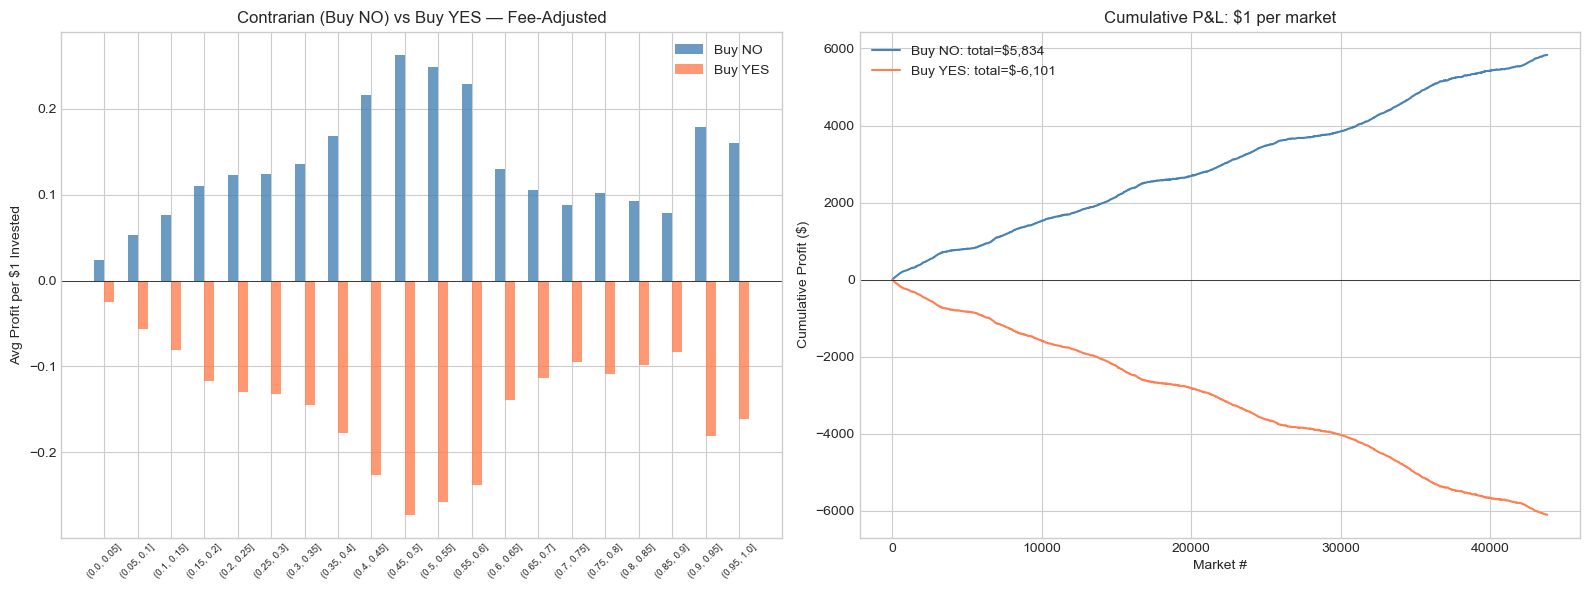


Overall results ($1 per market, 43,820 markets):
  Buy NO:  avg profit = $0.1331/trade, total = $5,834
  Buy YES: avg profit = $-0.1392/trade, total = $-6,101
  Buy NO win rate: 72.7%
  Buy YES win rate: 27.3%

Best price zones for Buy NO (avg profit > $0.05):
  (0.05, 0.1]: avg profit=$0.053, n=3,612.0
  (0.1, 0.15]: avg profit=$0.077, n=2,208.0
  (0.15, 0.2]: avg profit=$0.111, n=1,896.0
  (0.2, 0.25]: avg profit=$0.123, n=1,745.0
  (0.25, 0.3]: avg profit=$0.124, n=1,653.0
  (0.3, 0.35]: avg profit=$0.136, n=1,580.0
  (0.35, 0.4]: avg profit=$0.169, n=1,745.0
  (0.4, 0.45]: avg profit=$0.216, n=2,030.0
  (0.45, 0.5]: avg profit=$0.263, n=3,546.0
  (0.5, 0.55]: avg profit=$0.249, n=4,049.0
  (0.55, 0.6]: avg profit=$0.229, n=1,961.0
  (0.6, 0.65]: avg profit=$0.130, n=1,370.0
  (0.65, 0.7]: avg profit=$0.105, n=1,224.0
  (0.7, 0.75]: avg profit=$0.088, n=1,135.0
  (0.75, 0.8]: avg profit=$0.102, n=1,055.0
  (0.8, 0.85]: avg profit=$0.093, n=1,069.0
  (0.85, 0.9]: avg profit=$0.079, 

In [8]:
o = outcomes.copy()
o["lastTradePrice"] = pd.to_numeric(o["lastTradePrice"], errors="coerce")
o = o.dropna(subset=["lastTradePrice"])
o = o[(o["lastTradePrice"] > 0.01) & (o["lastTradePrice"] < 0.99)]

fee_rate = 200

o["no_price"] = 1 - o["lastTradePrice"]
o["no_fee"] = o["no_price"] * (1 - o["no_price"]) * fee_rate / 10000
o["no_cost"] = o["no_price"] + o["no_fee"]
o["no_payout"] = (o["outcome"] == 0).astype(float)
o["no_profit"] = o["no_payout"] - o["no_cost"]

o["yes_fee"] = o["lastTradePrice"] * (1 - o["lastTradePrice"]) * fee_rate / 10000
o["yes_cost"] = o["lastTradePrice"] + o["yes_fee"]
o["yes_payout"] = o["outcome"].astype(float)
o["yes_profit"] = o["yes_payout"] - o["yes_cost"]

o["price_bin"] = pd.cut(o["lastTradePrice"], bins=np.arange(0, 1.05, 0.05))
bin_stats = o.groupby("price_bin", observed=True).agg(
    n_markets=("outcome", "count"),
    yes_win_rate=("outcome", "mean"),
    avg_no_profit=("no_profit", "mean"),
    avg_yes_profit=("yes_profit", "mean"),
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = range(len(bin_stats))
axes[0].bar([i - 0.15 for i in x], bin_stats["avg_no_profit"], width=0.3,
            label="Buy NO", color="steelblue", alpha=0.8)
axes[0].bar([i + 0.15 for i in x], bin_stats["avg_yes_profit"], width=0.3,
            label="Buy YES", color="coral", alpha=0.8)
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(b) for b in bin_stats.index], rotation=45, fontsize=7)
axes[0].set_ylabel("Avg Profit per $1 Invested")
axes[0].set_title("Contrarian (Buy NO) vs Buy YES — Fee-Adjusted")
axes[0].legend()

cumulative_no = o["no_profit"].cumsum()
cumulative_yes = o["yes_profit"].cumsum()

axes[1].plot(cumulative_no.values, label=f"Buy NO: total=${cumulative_no.iloc[-1]:,.0f}", color="steelblue")
axes[1].plot(cumulative_yes.values, label=f"Buy YES: total=${cumulative_yes.iloc[-1]:,.0f}", color="coral")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_xlabel("Market #")
axes[1].set_ylabel("Cumulative Profit ($)")
axes[1].set_title("Cumulative P&L: $1 per market")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nOverall results ($1 per market, {len(o):,} markets):")
print(f"  Buy NO:  avg profit = ${o['no_profit'].mean():.4f}/trade, total = ${o['no_profit'].sum():,.0f}")
print(f"  Buy YES: avg profit = ${o['yes_profit'].mean():.4f}/trade, total = ${o['yes_profit'].sum():,.0f}")
print(f"  Buy NO win rate: {(o['no_profit'] > 0).mean():.1%}")
print(f"  Buy YES win rate: {(o['yes_profit'] > 0).mean():.1%}")

print(f"\nBest price zones for Buy NO (avg profit > $0.05):")
good_bins = bin_stats[bin_stats["avg_no_profit"] > 0.05]
for idx, row in good_bins.iterrows():
    print(f"  {idx}: avg profit=${row['avg_no_profit']:.3f}, n={row['n_markets']:,}")

In [9]:
audit = pd.DataFrame([

    {"Source": "Chan Ch.2", "Theory": "Strategy checklist: Sharpe>1, drawdown, costs, survivorship, data-snooping",
     "Covered?": "PARTIAL", "Gap": "Need ±20% param sensitivity test, explicit survivorship check",
     "Action": "Phase 5: parameter perturbation test on all strategies"},
    {"Source": "Chan Ch.2", "Theory": "Data-snooping: fewer params → more robust",
     "Covered?": "NO", "Gap": "No discussion of overfitting risk per strategy",
     "Action": "Contrarian (#8) lowest risk (1 param: buy NO). ML (#1) highest risk (33 features)"},
    {"Source": "Chan Ch.3", "Theory": "Survivorship bias: include resolved/closed markets",
     "Covered?": "YES", "Gap": "—", "Action": "Already using 321K resolved markets"},
    {"Source": "Chan Ch.5", "Theory": "Execution: limit orders > market orders",
     "Covered?": "NO", "Gap": "Not in implementation plan",
     "Action": "ALL strategies: post limit orders, never cross spread unless urgent"},
    {"Source": "Chan Ch.6", "Theory": "Kelly f*=μ/σ², Half-Kelly, continuous rebalancing",
     "Covered?": "YES", "Gap": "—", "Action": "In risk parameters"},
    {"Source": "Chan Ch.7", "Theory": "Regime switching: MR ↔ Momentum. PM: pre-event(MR) → event(Mom) → post(MR)",
     "Covered?": "NO", "Gap": "No regime detection in strategy plan",
     "Action": "Phase 3: regime feature (vol regime, HMM). Phase 4: regime-conditional models"},
    {"Source": "Chan Ch.7", "Theory": "Cointegration for pairs trading: spread deviation → reversion",
     "Covered?": "YES", "Gap": "—", "Action": "Tier 3 #5 (330 pairs, half-life 0.8d)"},
    {"Source": "Chan Ch.7", "Theory": "Seasonality: election cycles, sports seasons, crypto events",
     "Covered?": "NO", "Gap": "No seasonal analysis done",
     "Action": "Phase 3: add category-specific seasonal features (sports schedule, election calendar)"},

    {"Source": "Triple Barrier", "Theory": "CUSUM bars h=2% + Triple Barrier 5% + ResNet-LSTM",
     "Covered?": "YES", "Gap": "—", "Action": "Tier 2 #3 implementation"},
    {"Source": "Triple Barrier", "Theory": "XGBoost: highest accuracy BUT not most profitable",
     "Covered?": "YES", "Gap": "—", "Action": "Use profit-based metrics, not accuracy"},
    {"Source": "Triple Barrier", "Theory": "Dynamic volatility-adjusted barriers NOT better",
     "Covered?": "NO", "Gap": "Not mentioned — could waste time trying",
     "Action": "Skip dynamic barriers. Include vol as FEATURE instead"},
    {"Source": "Triple Barrier", "Theory": "Strategy works BETTER in high-vol markets",
     "Covered?": "NO", "Gap": "No vol-regime filtering in plan",
     "Action": "Phase 4: only trade when realized vol > threshold (skip low-vol regime)"},

    {"Source": "Matched Filter", "Theory": "S_MC=flow/liquidity for whales, S_TV=flow/volume for algo",
     "Covered?": "YES", "Gap": "—", "Action": "Tier 2 #4, confirmed in Phase 2.3 (corr=0.408)"},
    {"Source": "Matched Filter", "Theory": "Participation rate fallacy (Jensen's inequality)",
     "Covered?": "NO", "Gap": "Not warned explicitly",
     "Action": "Phase 3: NEVER use flow/volume for whale signal. Always S_MC"},
    {"Source": "Matched Filter", "Theory": "No sign reversal at longer horizons → genuine information",
     "Covered?": "NO", "Gap": "Not tested on our data",
     "Action": "Phase 3: test whale signal persistence at 1h, 4h, 24h horizons"},

    {"Source": "AFML", "Theory": "PurgedKFold + Sequential Bootstrap for temporal data",
     "Covered?": "YES", "Gap": "—", "Action": "Phase 4: use finance_ml_afml code"},
    {"Source": "AFML", "Theory": "Fractional differentiation: min d for stationarity",
     "Covered?": "NO", "Gap": "Not in feature plan",
     "Action": "Phase 3: apply frac_diff_FFD to price series before feature engineering"},
    {"Source": "AFML", "Theory": "Sample weights: 1/concurrent_events",
     "Covered?": "NO", "Gap": "Not in training plan",
     "Action": "Phase 4: use get_num_co_events() for sample weighting"},

    {"Source": "PMBench", "Theory": "Episode-based backtest: metadata + orderbook + trades + settlement",
     "Covered?": "PARTIAL", "Gap": "Mentioned but not adopted as data format",
     "Action": "Phase 5: structure backtest data as episodes"},
    {"Source": "PMBench", "Theory": "Fee-aware evaluation mandatory (naive activity = negative P&L)",
     "Covered?": "YES", "Gap": "—", "Action": "All backtests include fees"},

    {"Source": "docs/12 §2", "Theory": "Net inflow as leading indicator (surge predicts direction)",
     "Covered?": "NO", "Gap": "Missing from features list entirely",
     "Action": "Phase 3: net_inflow = mint - burn per market per period. Key feature"},
    {"Source": "docs/12 §2", "Theory": "Kyle's λ: 0.518(new) → 0.01(mature). Phase 2.3: mean=0.00013",
     "Covered?": "PARTIAL", "Gap": "λ not used as strategy selector",
     "Action": "Trade NEW markets (high λ) with small limit orders = more impact per $"},
    {"Source": "docs/12 §4", "Theory": "Maker advantage: makers outperform takers systematically",
     "Covered?": "NO", "Gap": "Not reflected in execution plan",
     "Action": "ALWAYS use limit orders (maker). Never market orders except kill-switch"},
    {"Source": "docs/12 §5", "Theory": "6 profit models: info arb, cross-platform, bonds, MM, domain, speed",
     "Covered?": "PARTIAL", "Gap": "Domain specialization model not explicit",
     "Action": "Consider specializing in 1-2 categories after Phase 4 results"},
    {"Source": "docs/12 §6", "Theory": "Dual-loop architecture: async WSS + sync pipeline + BookCache",
     "Covered?": "NO", "Gap": "Architecture not in implementation plan",
     "Action": "Phase 7: adopt dual-loop from docs/12 §6 (BookCache + graceful degradation)"},

    {"Source": "docs/13", "Theory": "Tick sizes: 0.1/0.01/0.001/0.0001 — price MUST match",
     "Covered?": "NO", "Gap": "Not in execution notes",
     "Action": "Phase 5-7: round prices to valid tick sizes before order placement"},
    {"Source": "docs/13", "Theory": "BUY market order: amount=USD; SELL: amount=shares",
     "Covered?": "NO", "Gap": "Not in execution notes",
     "Action": "Phase 7: careful with order construction (asymmetric params)"},

    {"Source": "Phase 2.3", "Theory": "Top 1% (309 traders) = 61.5% volume. Whale avg $851 vs retail $47",
     "Covered?": "NO", "Gap": "Updated numbers not in sec 1 findings table",
     "Action": "Integrate below"},
    {"Source": "Phase 2.3", "Theory": "Peak hour: 1:00 UTC. Weekend/weekday vol ratio: 0.10",
     "Covered?": "NO", "Gap": "Temporal features not in Phase 3 plan",
     "Action": "Phase 3: hour_sin/cos, weekday_sin/cos, is_weekend features"},
    {"Source": "Phase 2.3", "Theory": "S_MC vs S_TV correlation = 0.408. Normalization matters empirically",
     "Covered?": "NO", "Gap": "Empirical confirmation not referenced",
     "Action": "Strengthens Matched Filter theory. Use S_MC for whale tracking"},
    {"Source": "Phase 2.3", "Theory": "8 features identified for Phase 3",
     "Covered?": "NO", "Gap": "Not in Phase 3 plan (sec 8)",
     "Action": "Integrate below"},

    {"Source": "GA paper", "Theory": "Walk-Forward Optimization with genetic algorithm for params",
     "Covered?": "NO", "Gap": "Only simple walk-forward mentioned",
     "Action": "Phase 5: consider GA for CUSUM threshold + barrier params optimization"},

    {"Source": "Bayesian Robust", "Theory": "Adversarial synthetic data for robustness testing",
     "Covered?": "NO", "Gap": "No robustness testing planned",
     "Action": "Phase 4-5: generate adversarial scenarios (flash crashes, regime changes)"},
])

coverage = audit["Covered?"].value_counts()
print("═══ KNOWLEDGE BASE COVERAGE AUDIT ═══\n")
print(f"Total items audited: {len(audit)}")
print(f"  YES (covered):     {coverage.get('YES', 0)}")
print(f"  PARTIAL:           {coverage.get('PARTIAL', 0)}")
print(f"  NO (gap):          {coverage.get('NO', 0)}")
print(f"\nCoverage rate: {(coverage.get('YES', 0) + coverage.get('PARTIAL', 0)*0.5) / len(audit):.0%}")

print(f"\n{'='*70}")
print(f"GAPS — Must address before Phase 3:")
print(f"{'='*70}")
gaps = audit[audit["Covered?"] == "NO"]
for _, row in gaps.iterrows():
    print(f"\n  [{row['Source']}] {row['Theory'][:70]}")
    print(f"    → {row['Action']}")

═══ KNOWLEDGE BASE COVERAGE AUDIT ═══



Total items audited: 33
  YES (covered):     8
  PARTIAL:           4
  NO (gap):          21

Coverage rate: 30%

GAPS — Must address before Phase 3:



  [Chan Ch.2] Data-snooping: fewer params → more robust
    → Contrarian (#8) lowest risk (1 param: buy NO). ML (#1) highest risk (33 features)

  [Chan Ch.5] Execution: limit orders > market orders
    → ALL strategies: post limit orders, never cross spread unless urgent

  [Chan Ch.7] Regime switching: MR ↔ Momentum. PM: pre-event(MR) → event(Mom) → post
    → Phase 3: regime feature (vol regime, HMM). Phase 4: regime-conditional models

  [Chan Ch.7] Seasonality: election cycles, sports seasons, crypto events
    → Phase 3: add category-specific seasonal features (sports schedule, election calendar)

  [Triple Barrier] Dynamic volatility-adjusted barriers NOT better
    → Skip dynamic barriers. Include vol as FEATURE instead

  [Triple Barrier] Strategy works BETTER in high-vol markets
    → Phase 4: only trade when realized vol > threshold (skip low-vol regime)

  [Matched Filter] Participation rate fallacy (Jensen's inequality)
    → Phase 3: NEVER use flow/volume for whale signa